In [28]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.preprocessing import OneHotEncoder
import time
from tqdm import tqdm

In [29]:
ratings = pd.read_csv('ratings.dat', sep='::', engine='python',
                      names=['UserID','MovieID','Rating','Timestamp'])
users   = pd.read_csv('users.dat',   sep='::', engine='python',
                      names=['UserID','Gender','Age','Occupation','Zip-code'])
movies  = pd.read_csv('movies.dat',  sep='::', engine='python',
                      names=['MovieID','Title','Genres'], encoding='latin-1')

In [30]:
# Define reward: 1 if rating is 5, 0 otherwise - Vectorized operation
ratings['Reward'] = (ratings['Rating'] == 5).astype(int)

# Create age buckets
age_bins = [0, 18, 25, 35, 45, 50, 56, 100]
age_labels = ['under18', '18-24', '25-34', '35-44', '45-49', '50-55', '56+']
users['AgeGroup'] = pd.cut(users['Age'], bins=age_bins, labels=age_labels)

# Get top N movies (by number of ratings)
N = 50
top_movies = ratings['MovieID'].value_counts().head(N).index.tolist()
filtered_ratings = ratings[ratings['MovieID'].isin(top_movies)]

In [35]:
filtered_ratings.head()

,UserID,MovieID,Rating,Reward,Timestamp
0,1,1193,5,1,978300760
4,1,2355,5,1,978824291
5,1,1197,3,0,978302268
9,1,919,4,0,978301368
15,1,2791,4,0,978302188


In [31]:
# Extract genres efficiently
all_genres = set()
movies['Genres'] = movies['Genres'].str.split('|')
for genres in movies['Genres']:
    all_genres.update(genres)
all_genres = sorted(list(all_genres))

# Genre encoding
for genre in all_genres:
    movies[genre] = movies['Genres'].apply(lambda x: 1 if genre in x else 0)

In [34]:
all_genres

['Action',
 'Adventure',
 'Animation',
 "Children's",
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western']

In [32]:

# Merge dataframes - Ensure we only select needed columns
user_features = users[['UserID', 'Gender', 'AgeGroup', 'Occupation']]
movie_features = movies[['MovieID'] + all_genres]
filtered_ratings = filtered_ratings[['UserID', 'MovieID', 'Rating', 'Reward', 'Timestamp']]

# Optimize merges
full_data = filtered_ratings.merge(user_features, on='UserID').merge(movie_features, on='MovieID')

# Sort data efficiently
full_data = full_data.sort_values('Timestamp')



In [33]:
user_features.head()

,UserID,Gender,AgeGroup,Occupation
0,1,F,under18,10
1,2,M,50-55,16
2,3,M,18-24,15
3,4,M,35-44,7
4,5,M,18-24,20


In [17]:
movie_features

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [1, 1, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [1, 0, 0, ..., 0, 0, 0]])

In [18]:
filtered_ratings.head()

,UserID,MovieID,Rating,Reward,Timestamp
0,1,1193,5,1,978300760
4,1,2355,5,1,978824291
5,1,1197,3,0,978302268
9,1,919,4,0,978301368
15,1,2791,4,0,978302188


In [13]:
full_data.head()

,UserID,MovieID,Rating,Reward,Timestamp,Gender,AgeGroup,Occupation,Action,Adventure,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,ArmIndex
104455,6040,858,4,0,956703932,M,18-24,6,1,0,...,0,0,0,0,0,0,0,0,0,24
61433,6040,593,5,1,956703954,M,18-24,6,0,0,...,0,0,0,0,0,0,1,0,0,9
7463,6040,919,5,1,956704191,M,18-24,6,0,1,...,0,0,1,0,0,0,0,0,0,44
14081,6040,527,5,1,956704219,M,18-24,6,0,0,...,0,0,0,0,0,0,0,1,0,17
72344,6040,318,4,0,956704257,M,18-24,6,0,0,...,0,0,0,0,0,0,0,0,0,23


In [19]:
# One-hot encoding
try:
    # Newer scikit-learn with improved performance
    gender_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    age_group_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    occupation_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
except TypeError:
    # Fallback to older version
    gender_encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
    age_group_encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
    occupation_encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')

# Transform data
gender_encoded = gender_encoder.fit_transform(full_data[['Gender']])
age_group_encoded = age_group_encoder.fit_transform(full_data[['AgeGroup']])
occupation_encoded = occupation_encoder.fit_transform(full_data[['Occupation']])
movie_features = full_data[all_genres].values

# Concatenate features
X = np.concatenate([gender_encoded, age_group_encoded, occupation_encoded, movie_features], axis=1)

# Create MovieID to index mapping for arms
movie_to_idx = {}
for idx, movie_id in enumerate(top_movies):
    movie_to_idx[movie_id] = idx
    
full_data['ArmIndex'] = full_data['MovieID'].map(movie_to_idx)

# Create final dataset with only needed columns
final_data = full_data[['UserID', 'MovieID', 'ArmIndex', 'Reward', 'Timestamp']].copy()

print(f"Final dataset shape: {final_data.shape}")
print(f"Number of unique users: {final_data['UserID'].nunique()}")
print(f"Number of unique movies (arms): {final_data['MovieID'].nunique()}")

Final dataset shape: (109804, 5)
Number of unique users: 6025
Number of unique movies (arms): 50


In [37]:
X

array([[0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 1., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 1., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.]])

In [44]:
contexts = []
for idx in range(100000):
    contexts.append(X[idx])

In [45]:
contexts[0]

array([0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [42]:
X.shape

(109804, 47)

In [38]:
final_data.head()

,UserID,MovieID,ArmIndex,Reward,Timestamp
104455,6040,858,24,0,956703932
61433,6040,593,9,1,956703954
7463,6040,919,44,1,956704191
14081,6040,527,17,1,956704219
72344,6040,318,23,0,956704257


## Random Policy

In [4]:
# Random Policy
def create_random_policy(n_arms):
    """Create a random policy"""
    # Initialize state
    state = {
        'n_arms': n_arms,
        'name': "Random Policy"
    }
    return state

def random_select_arm(state, context=None):
    """Select arm randomly"""
    return np.random.randint(state['n_arms'])
    
def random_update(state, arm, reward, context=None):
    """Update policy (no-op for random)"""
    pass  # Random policy doesn't need updates

## Epsilon Greedy

In [5]:
# Epsilon Greedy with no context
def create_epsilon_greedy(n_arms, epsilon=0.001):
    """Create epsilon greedy policy"""
    state = {
        'n_arms': n_arms,
        'epsilon': epsilon,
        'counts': np.zeros(n_arms),
        'values': np.zeros(n_arms),
        'name': "Epsilon No Context"
    }
    return state

def epsilon_greedy_select_arm(state, context=None):
    """Select arm using epsilon greedy"""
    if np.random.random() < state['epsilon']:
        return np.random.randint(state['n_arms'])
    else:
        return np.argmax(state['values'])
        
def epsilon_greedy_update(state, arm, reward, context=None):
    """Update epsilon greedy policy"""
    state['counts'][arm] += 1
    n = state['counts'][arm]
    value = state['values'][arm]
    state['values'][arm] = ((n-1)/n) * value + (1/n) * reward

## UCB

In [6]:
# UCB with no context
def create_ucb(n_arms, alpha=0.5):
    """Create UCB policy"""
    state = {
        'n_arms': n_arms,
        'alpha': alpha,
        'counts': np.zeros(n_arms),
        'values': np.zeros(n_arms),
        'name': "UCB No Context"
    }
    return state

def ucb_select_arm(state, context=None):
    """Select arm using UCB"""
    # Check for unexplored arms first
    zero_counts_indices = []
    for i in range(state['n_arms']):
        if state['counts'][i] == 0:
            zero_counts_indices.append(i)
            
    if len(zero_counts_indices) > 0:
        return zero_counts_indices[0]
                
    # Calculate UCB values
    total_counts = sum(state['counts'])
    ucb_values = []
    for i in range(state['n_arms']):
        bonus = state['alpha'] * np.sqrt(2 * np.log(total_counts) / state['counts'][i])
        ucb_values.append(state['values'][i] + bonus)
            
    return np.argmax(ucb_values)
        
def ucb_update(state, arm, reward, context=None):
    """Update UCB policy"""
    state['counts'][arm] += 1
    n = state['counts'][arm]
    value = state['values'][arm]
    state['values'][arm] = ((n-1)/n) * value + (1/n) * reward

##   Thompson Sampling

In [7]:
# Thompson Sampling with no context
def create_thompson_sampling(n_arms):
    """Create Thompson Sampling policy"""
    state = {
        'n_arms': n_arms,
        'alpha': np.ones(n_arms),  # Successes
        'beta': np.ones(n_arms),   # Failures
        'name': "TS No Context"
    }
    return state

def thompson_sampling_select_arm(state, context=None):
    """Select arm using Thompson Sampling"""
    # Sample from beta distribution for each arm
    samples = []
    for i in range(state['n_arms']):
        samples.append(np.random.beta(state['alpha'][i], state['beta'][i]))
    return np.argmax(samples)
        
def thompson_sampling_update(state, arm, reward, context=None):
    """Update Thompson Sampling policy"""
    if reward == 1:
        state['alpha'][arm] += 1
    else:
        state['beta'][arm] += 1

## Lin UCB

In [8]:
# LinUCB
def create_linucb(n_arms, dim, alpha=0.25, lambda_=1.0):
    """Create LinUCB policy"""
    # Initialize model parameters for each arm
    A_inv = []
    b = []
    theta = []
    
    identity = np.identity(dim)
    for _ in range(n_arms):
        A_inv.append(identity.copy())
        b.append(np.zeros((dim, 1)))
        theta.append(np.zeros((dim, 1)))
        
    state = {
        'n_arms': n_arms,
        'dim': dim,
        'alpha': alpha,
        'lambda_': lambda_,
        'A_inv': A_inv,
        'b': b,
        'theta': theta,
        'name': "LinUCB Ridge"
    }
    return state
        
def linucb_select_arm(state, context):
    """Select arm using LinUCB"""
    context = context.reshape(-1, 1)  # Reshape to column vector
    
    ucb_values = np.zeros(state['n_arms'])
    
    for arm in range(state['n_arms']):
        # Calculate theta for this arm
        state['theta'][arm] = state['A_inv'][arm] @ state['b'][arm]
        
        # Calculate UCB
        cb = state['alpha'] * np.sqrt((context.T @ state['A_inv'][arm] @ context)[0, 0])
        ucb_values[arm] = (state['theta'][arm].T @ context)[0, 0] + cb
            
    return np.argmax(ucb_values)
        
def linucb_update(state, arm, reward, context):
    """Update LinUCB policy"""
    context = context.reshape(-1, 1)  # Reshape to column vector
    
    # Update precision matrix
    A = np.linalg.inv(state['A_inv'][arm])
    A += context @ context.T
    state['A_inv'][arm] = np.linalg.inv(A)
    
    # Update weighted feature vector
    state['b'][arm] += reward * context
    
    # Update theta
    state['theta'][arm] = state['A_inv'][arm] @ state['b'][arm]

## Epsilon Greedy with Ridge Regression

In [9]:
# Epsilon Greedy with Ridge Regression
def create_epsilon_greedy_ridge(n_arms, dim, epsilon=0.1, alpha=1.0):
    """Create Epsilon Greedy with Ridge Regression policy"""
    models = []
    X = []
    y = []
    
    for _ in range(n_arms):
        models.append(Ridge(alpha=alpha, fit_intercept=False, solver='auto'))
        X.append([])
        y.append([])
        
    state = {
        'n_arms': n_arms,
        'dim': dim,
        'epsilon': epsilon,
        'alpha': alpha,
        'models': models,
        'X': X,
        'y': y,
        'name': "Epsilon Ridge"
    }
    return state
        
def epsilon_greedy_ridge_select_arm(state, context):
    """Select arm using Epsilon Greedy with Ridge Regression"""
    # Exploration
    if np.random.random() < state['epsilon']:
        return np.random.randint(state['n_arms'])
    
    # Exploitation: predict reward for each arm
    values = np.zeros(state['n_arms'])
    
    for arm in range(state['n_arms']):
        if len(state['X'][arm]) > 0:
            try:
                # Stack features and targets
                X_train = np.vstack(state['X'][arm])
                y_train = np.array(state['y'][arm])
                state['models'][arm].fit(X_train, y_train)
                values[arm] = state['models'][arm].predict([context])[0]
            except:
                values[arm] = 0
        else:
            values[arm] = 0
                
    return np.argmax(values)
        
def epsilon_greedy_ridge_update(state, arm, reward, context):
    """Update Epsilon Greedy with Ridge Regression policy"""
    state['X'][arm].append(context)
    state['y'][arm].append(reward)

## Epsilon Greedy with Logistic Regression

In [10]:
# Epsilon Greedy with Logistic Regression
def create_epsilon_greedy_logistic(n_arms, dim, epsilon=0.1, C=1.0):
    """Create Epsilon Greedy with Logistic Regression policy"""
    models = []
    X = []
    y = []
    
    for _ in range(n_arms):
        models.append(LogisticRegression(C=C, max_iter=1000, solver='liblinear', 
                                      fit_intercept=False, warm_start=True))
        X.append([])
        y.append([])
        
    state = {
        'n_arms': n_arms,
        'dim': dim,
        'epsilon': epsilon,
        'C': C,
        'models': models,
        'X': X,
        'y': y,
        'name': "Epsilon Logistic"
    }
    return state
        
def epsilon_greedy_logistic_select_arm(state, context):
    """Select arm using Epsilon Greedy with Logistic Regression"""
    # Exploration
    if np.random.random() < state['epsilon']:
        return np.random.randint(state['n_arms'])
    
    # Exploitation: predict reward for each arm
    values = np.zeros(state['n_arms'])
    
    for arm in range(state['n_arms']):
        # Check if we have data and more than one class
        unique_y = set()
        for val in state['y'][arm]:
            unique_y.add(val)
            
        if len(state['X'][arm]) > 0 and len(unique_y) > 1:
            try:
                X_train = np.vstack(state['X'][arm])
                y_train = np.array(state['y'][arm])
                state['models'][arm].fit(X_train, y_train)
                values[arm] = state['models'][arm].predict_proba([context])[0][1]
            except Exception:
                values[arm] = 0
        else:
            values[arm] = 0
                
    return np.argmax(values)
        
def epsilon_greedy_logistic_update(state, arm, reward, context):
    """Update Epsilon Greedy with Logistic Regression policy"""
    state['X'][arm].append(context)
    state['y'][arm].append(reward)


## Thompson sample with Online Logistic Regression

In [11]:
# Thompson Sampling with Online Logistic Regression
def create_thompson_sampling_olr(n_arms, dim, alpha=0.001):
    """Create Thompson Sampling with Online Logistic Regression policy"""
    B = []
    mu = []
    f = []
    
    identity = np.identity(dim) * alpha
    for _ in range(n_arms):
        B.append(identity.copy())
        mu.append(np.zeros(dim))
        f.append(np.zeros(dim))
        
    state = {
        'n_arms': n_arms,
        'dim': dim,
        'alpha': alpha,
        'B': B,
        'mu': mu,
        'f': f,
        'name': "TS OLR"
    }
    return state

def sigmoid(x):
    """Stable sigmoid implementation"""
    if x >= 0:
        return 1 / (1 + np.exp(-x))
    else:
        return np.exp(x) / (1 + np.exp(x))
        
def sample_beta(state, arm):
    """Sample from multivariate Gaussian"""
    try:
        cov = np.linalg.inv(state['B'][arm])
        # Add small regularization for numerical stability
        for i in range(cov.shape[0]):
            cov[i, i] += 1e-8
        return np.random.multivariate_normal(state['mu'][arm], cov)
    except np.linalg.LinAlgError:
        # If inversion fails, return the mean
        return state['mu'][arm]
    
def thompson_sampling_olr_select_arm(state, context):
    """Select arm using Thompson Sampling with Online Logistic Regression"""
    values = np.zeros(state['n_arms'])
    
    for arm in range(state['n_arms']):
        # Sample beta from posterior
        beta = sample_beta(state, arm)
        
        # Predict reward
        pred = 0
        for i in range(len(context)):
            pred += beta[i] * context[i]
        values[arm] = sigmoid(pred)
            
    return np.argmax(values)
    
def thompson_sampling_olr_update(state, arm, reward, context):
    """Update Thompson Sampling with Online Logistic Regression policy"""
    # Update weighted sum
    for i in range(len(context)):
        state['f'][arm][i] += reward * context[i]
        
    # Update precision matrix
    pred = 0
    for i in range(len(context)):
        pred += state['mu'][arm][i] * context[i]
    p = sigmoid(pred)
    
    # Outer product
    for i in range(len(context)):
        for j in range(len(context)):
            state['B'][arm][i, j] += context[i] * context[j] * p * (1-p)
        
    # Update mean
    try:
        state['mu'][arm] = np.linalg.solve(state['B'][arm], state['f'][arm])
    except np.linalg.LinAlgError:
        # Use regularization
        regularized_B = state['B'][arm].copy()
        for i in range(regularized_B.shape[0]):
            regularized_B[i, i] += 1e-4
        state['mu'][arm] = np.linalg.solve(regularized_B, state['f'][arm])

Setting up bandit algorithms...
Running replay evaluation on 100000 samples...


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [7:08:14<00:00,  3.89it/s]


Execution time: 25694.08 seconds

Final cumulative rewards:
Random Policy: 890.0
Epsilon No Context: 1660.0
UCB No Context: 948.0
TS No Context: 1224.0
LinUCB Ridge: 946.0
Epsilon Ridge: 1196.0
Epsilon Logistic: 1210.0
TS OLR: 853.0


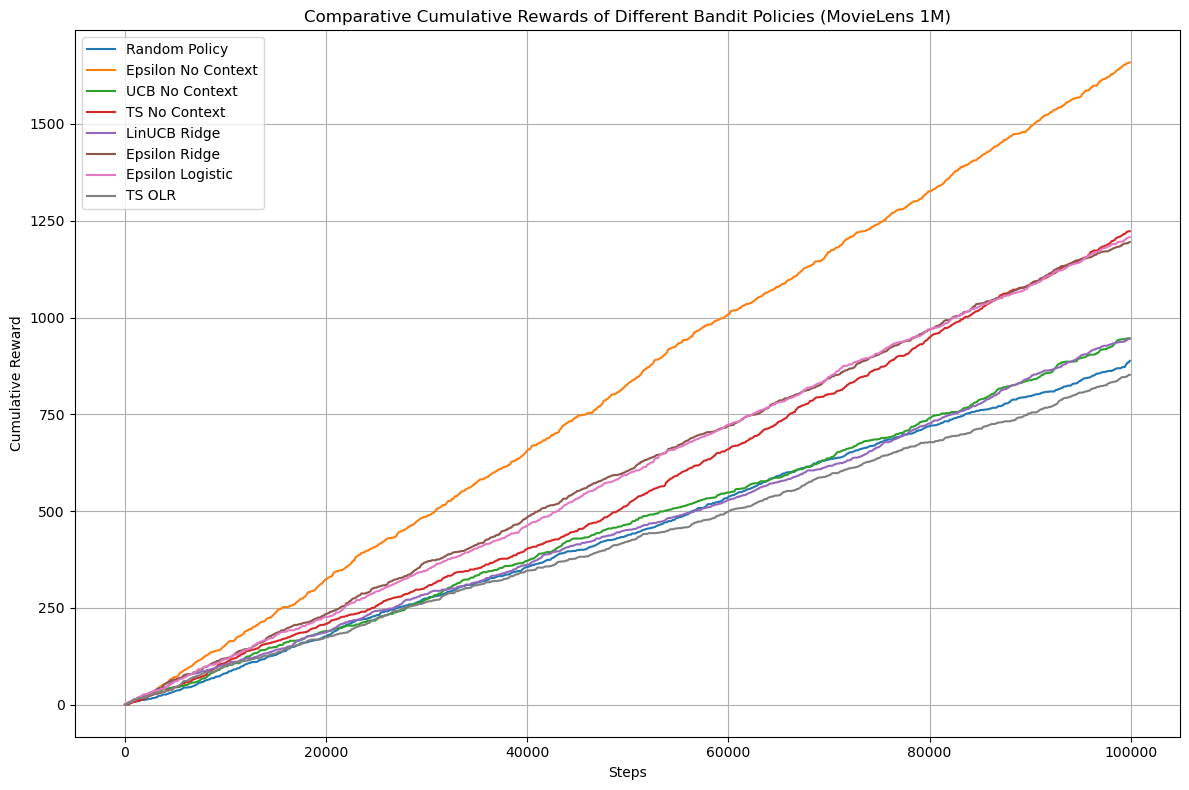


Summary table:
Policy                    Reward     Time (s)  
---------------------------------------------
Random Policy             890.0      25694.1   
Epsilon No Context        1660.0     25694.1   
UCB No Context            948.0      25694.1   
TS No Context             1224.0     25694.1   
LinUCB Ridge              946.0      25694.1   
Epsilon Ridge             1196.0     25694.1   
Epsilon Logistic          1210.0     25694.1   
TS OLR                    853.0      25694.1   


In [12]:
# Optimized replay evaluation with functions
def replay_evaluation(data, policies, n_arms, X):
    """
    Evaluate policies using the replay method - optimized version
    """
    # Pre-allocate results arrays
    n_samples = len(data)
    results = {}
    cum_rewards = {}
    
    for policy in policies:
        results[policy['name']] = np.zeros(n_samples)
        cum_rewards[policy['name']] = 0
    
    # Prepare data for faster access
    contexts = []
    for idx in range(n_samples):
        contexts.append(X[idx])
        
    arm_indices = data['ArmIndex'].values
    rewards = data['Reward'].values
    
    # Track execution time
    start_time = time.time()
    
    # Iterate through data points
    for idx in tqdm(range(n_samples)):
        context = contexts[idx]
        actual_arm = arm_indices[idx]
        reward = rewards[idx]
        
        # For each policy
        for policy in policies:
            # Get action from policy
            if policy['name'] in ["Random Policy", "Epsilon No Context", "UCB No Context", "TS No Context"]:
                if policy['name'] == "Random Policy":
                    selected_arm = random_select_arm(policy)
                elif policy['name'] == "Epsilon No Context":
                    selected_arm = epsilon_greedy_select_arm(policy)
                elif policy['name'] == "UCB No Context":
                    selected_arm = ucb_select_arm(policy)
                elif policy['name'] == "TS No Context":
                    selected_arm = thompson_sampling_select_arm(policy)
            else:
                if policy['name'] == "LinUCB Ridge":
                    selected_arm = linucb_select_arm(policy, context)
                elif policy['name'] == "Epsilon Ridge":
                    selected_arm = epsilon_greedy_ridge_select_arm(policy, context)
                elif policy['name'] == "Epsilon Logistic":
                    selected_arm = epsilon_greedy_logistic_select_arm(policy, context)
                elif policy['name'] == "TS OLR":
                    selected_arm = thompson_sampling_olr_select_arm(policy, context)
            
            # Apply reward only if the selected arm matches the logged arm
            policy_reward = reward if selected_arm == actual_arm else 0
            
            # Update policy
            if policy['name'] in ["Random Policy", "Epsilon No Context", "UCB No Context", "TS No Context"]:
                if policy['name'] == "Random Policy":
                    random_update(policy, selected_arm, policy_reward)
                elif policy['name'] == "Epsilon No Context":
                    epsilon_greedy_update(policy, selected_arm, policy_reward)
                elif policy['name'] == "UCB No Context":
                    ucb_update(policy, selected_arm, policy_reward)
                elif policy['name'] == "TS No Context":
                    thompson_sampling_update(policy, selected_arm, policy_reward)
            else:
                if policy['name'] == "LinUCB Ridge":
                    linucb_update(policy, selected_arm, policy_reward, context)
                elif policy['name'] == "Epsilon Ridge":
                    epsilon_greedy_ridge_update(policy, selected_arm, policy_reward, context)
                elif policy['name'] == "Epsilon Logistic":
                    epsilon_greedy_logistic_update(policy, selected_arm, policy_reward, context)
                elif policy['name'] == "TS OLR":
                    thompson_sampling_olr_update(policy, selected_arm, policy_reward, context)
            
            # Update cumulative reward
            cum_rewards[policy['name']] += policy_reward
            results[policy['name']][idx] = cum_rewards[policy['name']]
    
    end_time = time.time()
    execution_time = end_time - start_time
    
    return results, execution_time

# Run the experiment
print("Setting up bandit algorithms...")
n_arms = len(top_movies)
feature_dim = X.shape[1]

# Initialize policies as dictionaries
policies = [
    create_random_policy(n_arms),
    create_epsilon_greedy(n_arms, epsilon=0.1),
    create_ucb(n_arms, alpha=0.25),
    create_thompson_sampling(n_arms),
    create_linucb(n_arms, feature_dim, alpha=0.25),
    create_epsilon_greedy_ridge(n_arms, feature_dim, epsilon=0.1),
    create_epsilon_greedy_logistic(n_arms, feature_dim, epsilon=0.1),
    create_thompson_sampling_olr(n_arms, feature_dim, alpha=1.0)
]

# Sample for faster execution
sample_size = min(100000, len(final_data))
# Get random sample
sampled_data = final_data.sample(sample_size, random_state=42).reset_index(drop=True)
sampled_indices = sampled_data.index.tolist()
sampled_X = []
for idx in sampled_indices:
    sampled_X.append(X[idx])

print(f"Running replay evaluation on {len(sampled_data)} samples...")
results, execution_time = replay_evaluation(sampled_data, policies, n_arms, sampled_X)

print(f"Execution time: {execution_time:.2f} seconds")

# Calculate regrets but don't print them
baseline_rewards = results["Random Policy"]
regrets = {}

for policy_name, rewards in results.items():
    if policy_name != "Random Policy":
        regrets[policy_name] = rewards[-1] - baseline_rewards[-1]

print("\nFinal cumulative rewards:")
for policy_name, rewards in results.items():
    print(f"{policy_name}: {rewards[-1]}")



# Plotting
plt.figure(figsize=(12, 8))

# Plot cumulative rewards over time with subsampling
sample_interval = max(1, len(sampled_data) // 1000)
sample_points = []
for i in range(0, len(sampled_data), sample_interval):
    sample_points.append(i)

for policy_name, rewards in results.items():
    x_values = []
    y_values = []
    for i in sample_points:
        x_values.append(i)
        y_values.append(rewards[i])
    plt.plot(x_values, y_values, label=policy_name)

plt.title('Comparative Cumulative Rewards of Different Bandit Policies (MovieLens 1M)')
plt.xlabel('Steps')
plt.ylabel('Cumulative Reward')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('bandit_rewards_movielens.png')
plt.show()

# Modified summary table without worst regret
print("\nSummary table:")
print(f"{'Policy':<25} {'Reward':<10} {'Time (s)':<10}")
print("-" * 45)
for policy in policies:
    policy_name = policy['name']
    reward = results[policy_name][-1]
    print(f"{policy_name:<25} {reward:<10.1f} {execution_time:<10.1f}")